In [1]:
import pandas as pd
from pathlib import Path

In [42]:
base_dir = "/project2/ll_774_951/TwitterInfoOpsIU/YYYY_MM/"
files = list(Path(base_dir).rglob("*/*/*.csv.gz"))
len(files)

84

In [ ]:
from collections import defaultdict
from pathlib import Path
import time
import json
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from tqdm import tqdm

model = SentenceTransformer("intfloat/e5-base-v2")
embed_dim = 768
batch_size = 512
checkpoint_dir = Path("checkpoints")
checkpoint_dir.mkdir(exist_ok=True)

PROCESSED_FILE = checkpoint_dir / "processed_files.json"
SAVE_EVERY = 5          # save checkpoint every N files
SHARD_MAX_ROWS = 500_000  # max users per shard file


def prefix_texts(texts, prefix="passage: "):
    return [prefix + t for t in texts]


def _shard_path(shard_idx):
    return checkpoint_dir / f"state_{shard_idx:04d}.npz"


def save_checkpoint(tweet_sum, tweet_max, tweet_count,
                    bio_sum, bio_max, bio_count, user_bios,
                    processed_files):
    """Save all accumulators across sharded .npz files + metadata JSON."""
    all_uids = sorted(set(tweet_sum.keys()) | set(bio_sum.keys()))
    n_shards = (len(all_uids) + SHARD_MAX_ROWS - 1) // SHARD_MAX_ROWS

    # Remove any old shards beyond what we'll write now
    for old in checkpoint_dir.glob("state_*.npz"):
        old.unlink()

    for shard_idx in range(n_shards):
        start = shard_idx * SHARD_MAX_ROWS
        end = min(start + SHARD_MAX_ROWS, len(all_uids))
        shard_uids = all_uids[start:end]
        uid_array = np.array(shard_uids)

        t_sum = np.array([tweet_sum.get(u, np.zeros(embed_dim)) for u in shard_uids])
        t_max = np.array([tweet_max.get(u, np.full(embed_dim, -np.inf)) for u in shard_uids])
        t_cnt = np.array([tweet_count.get(u, 0) for u in shard_uids])

        b_sum = np.array([bio_sum.get(u, np.zeros(embed_dim)) for u in shard_uids])
        b_max = np.array([bio_max.get(u, np.full(embed_dim, -np.inf)) for u in shard_uids])
        b_cnt = np.array([bio_count.get(u, 0) for u in shard_uids])

        np.savez_compressed(
            _shard_path(shard_idx),
            uids=uid_array,
            tweet_sum=t_sum, tweet_max=t_max, tweet_count=t_cnt,
            bio_sum=b_sum, bio_max=b_max, bio_count=b_cnt,
        )

    # Save processed files + user_bios as JSON
    meta = {
        "processed_files": processed_files,
        "n_shards": n_shards,
        "shard_max_rows": SHARD_MAX_ROWS,
        "total_users": len(all_uids),
        "user_bios": {str(k): list(v) for k, v in user_bios.items()},
    }
    with open(PROCESSED_FILE, "w") as f:
        json.dump(meta, f)

    print(f"  [checkpoint] Saved {len(all_uids)} users across {n_shards} shard(s), "
          f"{len(processed_files)} files processed")


def load_checkpoint():
    """Restore accumulators and processed file list from sharded files."""
    tweet_sum = defaultdict(lambda: np.zeros(embed_dim, dtype=np.float64))
    tweet_max = defaultdict(lambda: np.full(embed_dim, -np.inf, dtype=np.float64))
    tweet_count = defaultdict(int)
    bio_sum = defaultdict(lambda: np.zeros(embed_dim, dtype=np.float64))
    bio_max = defaultdict(lambda: np.full(embed_dim, -np.inf, dtype=np.float64))
    bio_count = defaultdict(int)
    user_bios = defaultdict(set)
    processed_files = []

    if not PROCESSED_FILE.exists():
        print("No checkpoint found, starting fresh.")
        return (tweet_sum, tweet_max, tweet_count,
                bio_sum, bio_max, bio_count,
                user_bios, processed_files)

    with open(PROCESSED_FILE) as f:
        meta = json.load(f)

    processed_files = meta["processed_files"]
    n_shards = meta["n_shards"]

    for k, v in meta["user_bios"].items():
        try:
            key = int(k)
        except ValueError:
            key = k
        user_bios[key] = set(v)

    total_loaded = 0
    for shard_idx in range(n_shards):
        path = _shard_path(shard_idx)
        if not path.exists():
            print(f"  WARNING: missing shard {path}, skipping")
            continue
        data = np.load(path)
        uids = data["uids"]
        for i, uid in enumerate(uids):
            uid = int(uid) if np.issubdtype(type(uid), np.integer) else uid
            if data["tweet_count"][i] > 0:
                tweet_sum[uid] = data["tweet_sum"][i].astype(np.float64)
                tweet_max[uid] = data["tweet_max"][i].astype(np.float64)
                tweet_count[uid] = int(data["tweet_count"][i])
            if data["bio_count"][i] > 0:
                bio_sum[uid] = data["bio_sum"][i].astype(np.float64)
                bio_max[uid] = data["bio_max"][i].astype(np.float64)
                bio_count[uid] = int(data["bio_count"][i])
        total_loaded += len(uids)

    print(f"  Resumed: {len(processed_files)} files done, "
          f"{total_loaded} users from {n_shards} shard(s), "
          f"{sum(tweet_count.values()):,} tweets, "
          f"{sum(bio_count.values()):,} bios")

    return (tweet_sum, tweet_max, tweet_count,
            bio_sum, bio_max, bio_count,
            user_bios, processed_files)


# ── Load or initialize state ──
(tweet_sum, tweet_max, tweet_count,
 bio_sum, bio_max, bio_count,
 user_bios, processed_files) = load_checkpoint()

processed_set = set(processed_files)

base_dir = "/project2/ll_774_951/TwitterInfoOpsIU/YYYY_MM/"
files = list(Path(base_dir).rglob("*/*/*.csv.gz"))
import random
n = len(files)
files = random.sample(files, n)
print(f"Found {len(files)} files total, {len(processed_set)} already done")

total_rows = sum(tweet_count.values())
total_users = set(tweet_sum.keys())
t0 = time.time()
files_since_save = 0

for i, f in enumerate(files):
    if str(f) in processed_set:
        continue

    file_start = time.time()
    print(f"\n[{i+1}/{len(files)}] Reading ... {f.name}")
    df = pd.read_csv(f, compression="gzip", low_memory=False,
                     usecols=["userid", "tweet_text", "user_profile_description"])
    print(f"  Loaded {len(df):,} rows in {time.time() - file_start:.1f}s")

    # collect unique bios
    bio_before = sum(len(v) for v in user_bios.values())
    for uid, bio in zip(df["userid"], df["user_profile_description"]):
        if pd.notna(bio):
            user_bios[uid].add(bio.strip())
    bio_after = sum(len(v) for v in user_bios.values())
    print(f"  Collected {bio_after - bio_before} new unique bios (total: {bio_after})")

    # embed tweets
    texts = df["tweet_text"].fillna("").tolist()
    uids = df["userid"].values
    file_users = set(uids)
    total_users.update(file_users)

    n_batches = (len(df) + batch_size - 1) // batch_size
    for start in tqdm(range(0, len(df), batch_size),
                      total=n_batches,
                      desc=f"  Embedding tweets",
                      unit="batch"):
        end = min(start + batch_size, len(df))
        batch_texts = prefix_texts(texts[start:end])
        batch_uids = uids[start:end]
        embeddings = model.encode(batch_texts, normalize_embeddings=True,
                                  show_progress_bar=False)
        for uid, emb in zip(batch_uids, embeddings):
            tweet_sum[uid] += emb
            tweet_max[uid] = np.maximum(tweet_max[uid], emb)
            tweet_count[uid] += 1

    # embed bios for users in this file (incremental)
    file_bio_items = [(uid, bio) for uid in file_users
                      if uid in user_bios
                      for bio in user_bios[uid]]
    users_with_new_bios = {uid for uid in file_users if uid in user_bios}
    for uid in users_with_new_bios:
        bio_sum[uid] = np.zeros(embed_dim, dtype=np.float64)
        bio_max[uid] = np.full(embed_dim, -np.inf, dtype=np.float64)
        bio_count[uid] = 0
    if file_bio_items:
        for start in range(0, len(file_bio_items), batch_size):
            end = min(start + batch_size, len(file_bio_items))
            batch = file_bio_items[start:end]
            embeddings = model.encode(prefix_texts([b for _, b in batch]),
                                      normalize_embeddings=True,
                                      show_progress_bar=False)
            for (uid, _), emb in zip(batch, embeddings):
                bio_sum[uid] += emb
                bio_max[uid] = np.maximum(bio_max[uid], emb)
                bio_count[uid] += 1

    total_rows += len(df)
    elapsed = time.time() - t0

    processed_files.append(str(f))
    processed_set.add(str(f))
    files_since_save += 1

    print(f"  {len(df):,} rows, {len(file_users):,} users | "
          f"file took {time.time() - file_start:.1f}s | "
          f"cumulative: {total_rows:,} rows, {len(total_users):,} users, {elapsed:.1f}s")

    if files_since_save >= SAVE_EVERY:
        save_checkpoint(tweet_sum, tweet_max, tweet_count,
                        bio_sum, bio_max, bio_count, user_bios,
                        processed_files)
        files_since_save = 0

# Final save
save_checkpoint(tweet_sum, tweet_max, tweet_count,
                bio_sum, bio_max, bio_count, user_bios,
                processed_files)

# Finalize
tweet_mean = {uid: tweet_sum[uid] / tweet_count[uid] for uid in tweet_sum}
bio_mean = {uid: bio_sum[uid] / bio_count[uid] for uid in bio_sum}

print(f"\nTweet embeddings: {len(tweet_mean)} users, {sum(tweet_count.values()):,} tweets")
print(f"Bio embeddings: {len(bio_mean)} users, {sum(bio_count.values()):,} bios")
print(f"All done in {time.time() - t0:.1f}s")

No checkpoint found, starting fresh.
Found 84 files total, 0 already done

[1/84] Reading ... egypt_uae_082019_tweets_csv_unhashed.csv.gz
  Loaded 214,898 rows in 2.1s
  Collected 180 new unique bios (total: 180)


  Embedding tweets: 100%|██████████| 420/420 [13:54<00:00,  1.99s/batch]


  214,898 rows, 240 users | file took 837.3s | cumulative: 214,898 rows, 240 users, 837.3s

[2/84] Reading ... bangladesh_linked_tweets_csv_unhashed.csv.gz
  Loaded 26,212 rows in 0.2s
  Collected 10 new unique bios (total: 190)


  Embedding tweets: 100%|██████████| 52/52 [00:56<00:00,  1.08s/batch]


  26,212 rows, 11 users | file took 56.4s | cumulative: 241,110 rows, 251 users, 893.8s

[3/84] Reading ... serbia_022020_tweets_csv_unhashed_13.csv.gz
  Loaded 2,709,366 rows in 15.8s
  Collected 281 new unique bios (total: 471)


  Embedding tweets:   1%|          | 31/5292 [00:35<1:49:13,  1.25s/batch]

In [74]:
out_base = "retweet_ids/retweet_ids"
max_rows = 5_000_000
file_idx = 0
rows_in_current = 0
header_written = False

def out_path(idx):
    return f"{out_base}_{idx}.csv"

for f in files:
    print("reading... ", f)
    tmp = pd.read_csv(f, compression="gzip", low_memory=False,
                      usecols=["tweetid", "userid", "retweet_userid"])
    tmp = tmp[tmp.retweet_userid.notna()]
    tmp["source_file"] = str(f)
    tmp["retweet_userid"] = pd.to_numeric(tmp["retweet_userid"], errors="coerce")
    tmp["retweet_userid"] = tmp.retweet_userid.astype("Int64")

    start = 0
    while start < len(tmp):
        space_left = max_rows - rows_in_current
        chunk = tmp.iloc[start : start + space_left]
        print(f"appending {len(chunk)} rows to {out_path(file_idx)}...")
        chunk.to_csv(out_path(file_idx), mode="a",
                     header=(not header_written), index=False)
        header_written = True
        rows_in_current += len(chunk)
        start += len(chunk)

        if rows_in_current >= max_rows:
            file_idx += 1
            rows_in_current = 0
            header_written = False

reading...  /project2/ll_774_951/TwitterInfoOpsIU/YYYY_MM/2018_10/ira/ira_tweets_csv_unhashed.csv.gz
appending 3332424 rows to retweet_ids/retweet_ids_0.csv...
reading...  /project2/ll_774_951/TwitterInfoOpsIU/YYYY_MM/2019_01/venezuela_201901_1/venezuela_201901_1_tweets_csv_unhashed_1.csv.gz
appending 906318 rows to retweet_ids/retweet_ids_0.csv...
reading...  /project2/ll_774_951/TwitterInfoOpsIU/YYYY_MM/2019_08/egypt_uae_082019_1/egypt_uae_082019_tweets_csv_unhashed.csv.gz
appending 71883 rows to retweet_ids/retweet_ids_0.csv...
reading...  /project2/ll_774_951/TwitterInfoOpsIU/YYYY_MM/2019_11/saudi_arabia_112019/saudi_arabia_112019_tweets_csv_unhashed_4.csv.gz
appending 689375 rows to retweet_ids/retweet_ids_0.csv...
appending 858959 rows to retweet_ids/retweet_ids_1.csv...
reading...  /project2/ll_774_951/TwitterInfoOpsIU/YYYY_MM/2020_04/sa_eg_ae_022020/sa_eg_ae_022020_tweets_csv_unhashed_03.csv.gz
appending 3378670 rows to retweet_ids/retweet_ids_1.csv...
reading...  /project2/ll_

In [47]:
%%time

base_dir = "/project2/ll_774_951/TwitterInfoOpsIU/YYYY_MM/"
files = list(Path(base_dir).rglob("*/*/*.csv.gz"))
len(files)

import random
n = 10
files = random.sample(files, n)

dfs = []
for f in files[:n]:
    print('reading ', f)
    %time tmp = pd.read_csv(f, \
                      compression="gzip", \
                      low_memory=False, \
                      usecols=['tweetid', 'userid', 'retweet_userid'] \
                     )
    tmp = tmp[tmp.retweet_userid.notna()]
    # tmp = tmp.sample(min(len(tmp), 100))
    tmp["source_file"] = f
    dfs.append(tmp)
print('concatenating...')
df = pd.concat(dfs, ignore_index=True)

reading  /project2/ll_774_951/TwitterInfoOpsIU/YYYY_MM/2020_05/turkey_052020/turkey_052020_tweets_csv_unhashed_2017_06.csv.gz
CPU times: user 19.6 s, sys: 1.15 s, total: 20.7 s
Wall time: 21.1 s
reading  /project2/ll_774_951/TwitterInfoOpsIU/YYYY_MM/2020_04/serbia_022020/serbia_022020_tweets_csv_unhashed_04.csv.gz
CPU times: user 15.5 s, sys: 1.01 s, total: 16.5 s
Wall time: 16.8 s
reading  /project2/ll_774_951/TwitterInfoOpsIU/YYYY_MM/2019_01/venezuela_201901_1/venezuela_201901_1_tweets_csv_unhashed_1.csv.gz
CPU times: user 14 s, sys: 964 ms, total: 15 s
Wall time: 15.3 s
reading  /project2/ll_774_951/TwitterInfoOpsIU/YYYY_MM/2020_04/sa_eg_ae_022020/sa_eg_ae_022020_tweets_csv_unhashed_03.csv.gz
CPU times: user 21.6 s, sys: 1.3 s, total: 22.9 s
Wall time: 23.3 s
reading  /project2/ll_774_951/TwitterInfoOpsIU/YYYY_MM/2020_04/serbia_022020/serbia_022020_tweets_csv_unhashed_05.csv.gz
CPU times: user 14.1 s, sys: 922 ms, total: 15 s
Wall time: 15.3 s
reading  /project2/ll_774_951/TwitterIn

In [67]:
import pandas as pd
from itertools import combinations

# 1. Group by source_file and create a dictionary of sets
# Every set contains all unique userids and retweetids for that file
file_sets = df.groupby('source_file').apply(
    lambda x: set(x['userid']) | set(x['retweet_userid'])
).to_dict()

# 2. Get the count of unique IDs per file
file_sizes = {file: len(ids) for file, ids in file_sets.items()}

# 3. Calculate pairwise overlaps and include sizes
results = []
files = sorted(file_sets.keys())

# combinations(files, 2) automatically ignores (A, A) 
# and ensures we only get (A, B) but never (B, A)
for f1, f2 in combinations(files, 2):
    shared_ids = file_sets[f1].intersection(file_sets[f2])
    
    results.append({
        'file_1': f1,
        'file_2': f2,
        'file_1_n_rows': file_sizes[f1],
        'file_2_n_rows': file_sizes[f2],
        'overlap_count': len(shared_ids)
    })

# 4. Create final DataFrame
overlap_df = pd.DataFrame(results)

overlap_df

/tmp/SLURM_7168888/ipykernel_1608831/3646072391.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  file_sets = df.groupby('source_file').apply(


,file_1,file_2,file_1_n_rows,file_2_n_rows,overlap_count
0,/project2/ll_774_951/TwitterInfoOpsIU/YYYY_MM/...,/project2/ll_774_951/TwitterInfoOpsIU/YYYY_MM/...,205448,83712,734
1,/project2/ll_774_951/TwitterInfoOpsIU/YYYY_MM/...,/project2/ll_774_951/TwitterInfoOpsIU/YYYY_MM/...,205448,7508,88
2,/project2/ll_774_951/TwitterInfoOpsIU/YYYY_MM/...,/project2/ll_774_951/TwitterInfoOpsIU/YYYY_MM/...,205448,107334,951
3,/project2/ll_774_951/TwitterInfoOpsIU/YYYY_MM/...,/project2/ll_774_951/TwitterInfoOpsIU/YYYY_MM/...,205448,51966,426
4,/project2/ll_774_951/TwitterInfoOpsIU/YYYY_MM/...,/project2/ll_774_951/TwitterInfoOpsIU/YYYY_MM/...,205448,15754,912
5,/project2/ll_774_951/TwitterInfoOpsIU/YYYY_MM/...,/project2/ll_774_951/TwitterInfoOpsIU/YYYY_MM/...,205448,14412,865
6,/project2/ll_774_951/TwitterInfoOpsIU/YYYY_MM/...,/project2/ll_774_951/TwitterInfoOpsIU/YYYY_MM/...,205448,57855,787
7,/project2/ll_774_951/TwitterInfoOpsIU/YYYY_MM/...,/project2/ll_774_951/TwitterInfoOpsIU/YYYY_MM/...,205448,77900,335
8,/project2/ll_774_951/TwitterInfoOpsIU/YYYY_MM/...,/project2/ll_774_951/TwitterInfoOpsIU/YYYY_MM/...,205448,15118,1900
9,/project2/ll_774_951/TwitterInfoOpsIU/YYYY_MM/...,/project2/ll_774_951/TwitterInfoOpsIU/YYYY_MM/...,83712,7508,18


In [46]:
base_dir = "/project2/ll_774_951/TwitterInfoOpsIU/YYYY_MM/"
driver_files = list(Path(base_dir).rglob('*/control_driver_users.csv'))
len(driver_files)

import random
n = 5
files = random.sample(files, n)

dfs = []
for f in driver_files[:n]:
    print('reading ', f)
    tmp = pd.read_csv(f, 
                      low_memory=False, 
                      # usecols=['tweetid', 'userid']
                     ).sample(100)
    tmp["source_file"] = f
    dfs.append(tmp)
cdf = pd.concat(dfs, ignore_index=True)

reading  /project2/ll_774_951/TwitterInfoOpsIU/YYYY_MM/2018_10/ira/DriversControl/control_driver_users.csv
reading  /project2/ll_774_951/TwitterInfoOpsIU/YYYY_MM/2018_10/iranian/DriversControl/control_driver_users.csv
reading  /project2/ll_774_951/TwitterInfoOpsIU/YYYY_MM/2019_01/bangladesh_201901_1/DriversControl/control_driver_users.csv
reading  /project2/ll_774_951/TwitterInfoOpsIU/YYYY_MM/2019_01/iran_201901_1/DriversControl/control_driver_users.csv
reading  /project2/ll_774_951/TwitterInfoOpsIU/YYYY_MM/2019_01/russia_201901_1/DriversControl/control_driver_users.csv


In [4]:
def f(x):
    try:
        x = eval(x)
        return x
    except Exception:
        print(x)
df['retweet_userid'] = pd.to_numeric(df['retweet_userid'], errors='coerce')
df['retweet_userid'] = df.retweet_userid.astype('Int64')

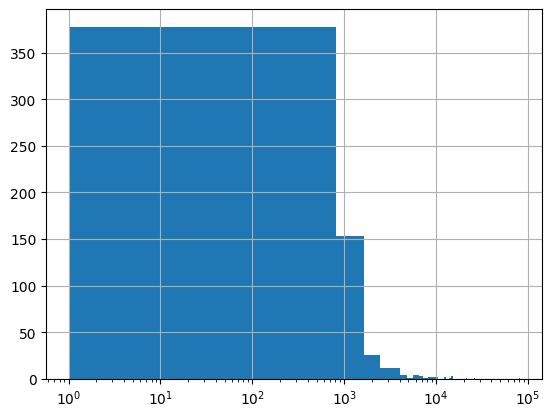

In [39]:
import matplotlib.pyplot as plt
df.userid.value_counts().hist(bins=100)
plt.xscale('log')

In [13]:
len(set(df.userid.unique()) | set(df.retweet_userid.unique()))

40359

In [5]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.from_pandas_edgelist(df, source='userid', target='retweet_userid', create_using=nx.DiGraph())

In [69]:
# Create dictionaries for mapping
in_dict = dict(G.in_degree())
out_dict = dict(G.out_degree())

# Map the dictionaries to the 'userid' column
df['in_deg'] = df['userid'].map(in_dict)
df['out_deg'] = df['userid'].map(out_dict)

# Fill NaNs with 0 (in case some userids in the DF aren't in the graph)
df[['in_deg', 'out_deg']] = df[['in_deg', 'out_deg']].fillna(0).astype(int)

df['deg'] = df.in_deg + df.out_deg

In [75]:
t = df.drop_duplicates('userid')
t.in_deg.eq(1).mean()

0.06974159488746874

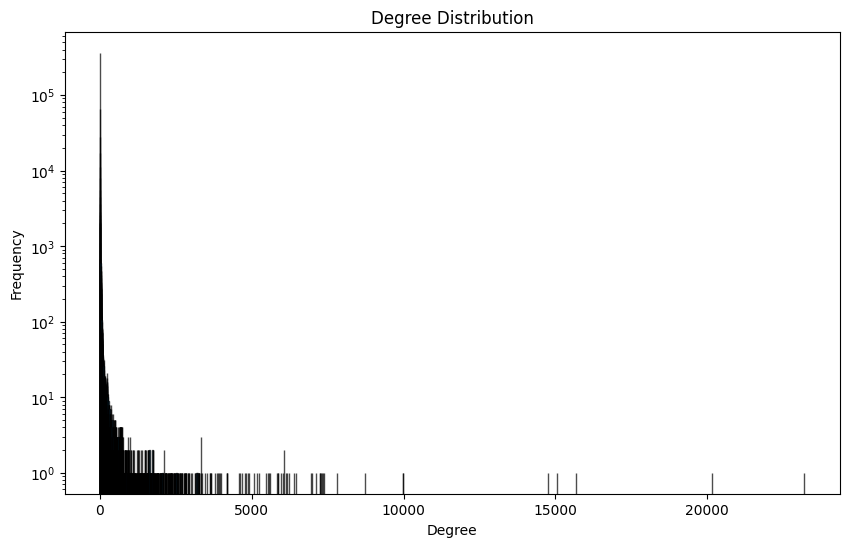

In [29]:
degrees = [d for n, d in G.degree()]

plt.figure(figsize=(10, 6))
plt.hist(degrees, bins=range(1, max(degrees) + 2), edgecolor='black', alpha=0.7)
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.yscale('log')
plt.title('Degree Distribution')
plt.show()